✅ Config Loaded.
[INFO] 21:16:21 - Scanning Data...
   + Loaded: merged_data_prepared.csv [TRAIN]
   + Loaded: model_test_devID109_15_percent_test_data_prepared.csv [TEST]
[INFO] 21:16:22 - Feature Engineering...
[INFO] 21:16:23 - Using 17 specific features.

🚀 HORIZON: +0 Mins
[INFO] 21:16:23 - Optuna Optimization...
   🏆 Best Params: {'n_estimators': 432, 'learning_rate': 0.10287633970740709, 'max_depth': 9, 'subsample': 0.6142430084744258, 'colsample_bytree': 0.6177058055430682, 'min_child_weight': 2, 'gamma': 1.2866067833043293}
[INFO] 21:18:46 - Training Final Model...

==================== TRAIN Set (Balanced) - H0 ====================
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      5000
     Warning       1.00      1.00      1.00      5000
    Critical       1.00      1.00      1.00      5000

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00 

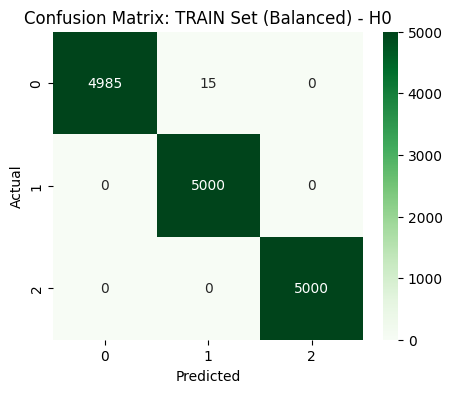


==================== VALIDATION Set - H0 ====================
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      6646
     Warning       0.31      1.00      0.47        30
    Critical       0.86      1.00      0.92         6

    accuracy                           0.99      6682
   macro avg       0.72      1.00      0.80      6682
weighted avg       1.00      0.99      0.99      6682



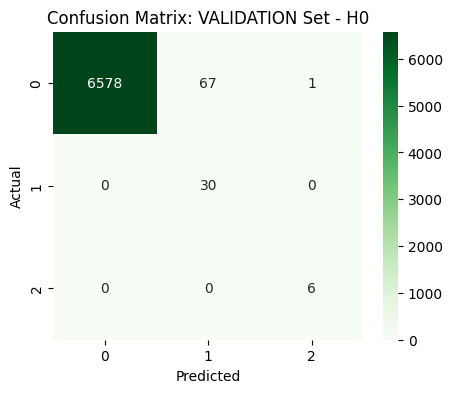


==================== TEST Set (Standard) - H0 ====================
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98      9359
     Warning       0.50      0.96      0.66       291
    Critical       0.75      0.67      0.71        27

    accuracy                           0.97      9677
   macro avg       0.75      0.86      0.78      9677
weighted avg       0.98      0.97      0.97      9677



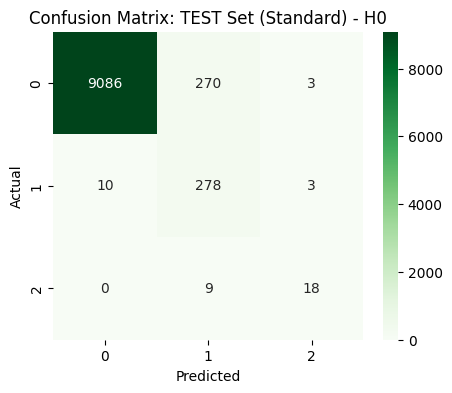

   🔥 Best Thresholds -> Crit: 0.25, Warn: 0.20

==================== TEST Set (Safety Tuned) - H0 ====================
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97      9359
     Warning       0.35      0.95      0.51       291
    Critical       0.56      0.93      0.69        27

    accuracy                           0.94      9677
   macro avg       0.63      0.94      0.73      9677
weighted avg       0.98      0.94      0.96      9677



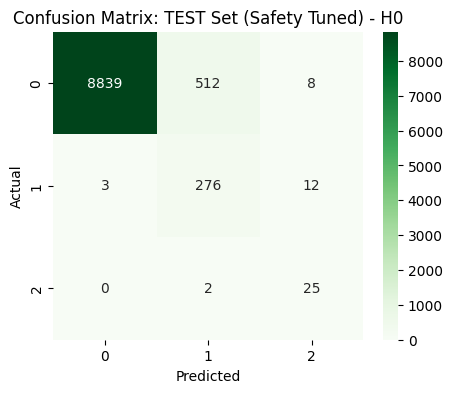


=== SUMMARY ===
   Horizon  F1_Critical
0        0     0.694444


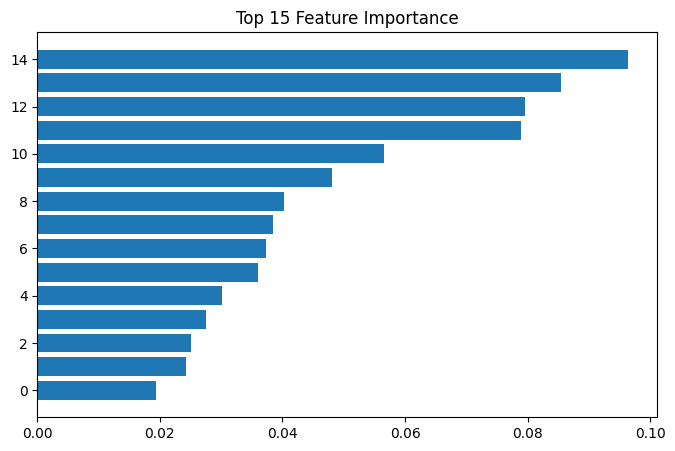

In [ ]:
# %%
# ====================================================================
# 1. IMPORTS & CONFIGURATION
# ====================================================================
import os
import glob
import time
import json
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Advanced Models
import optuna 
import xgboost as xgb
from tensorflow.keras.models import load_model 

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score

import warnings
warnings.filterwarnings('ignore')

class Config:
    # --- PATHS ---
    DATA_DIR = "./dataMA/"
    MODEL_DIR = "./model/xgboost_specific/" 
    SCALER_PATH = "./model/xgboost_specific_scaler.save"
    
    # External Models
    ISO_MODEL_PATH = './../models/IsolationForest/model/iso_model2.joblib'
    ISO_SCALER_PATH = './../models/IsolationForest/model/iso_scaler2.joblib'
    LSTM_MODEL_PATH = './../models/LSTM_Autoencoders/lstm_autoencoder_model_fit.h5'
    LSTM_SCALER_PATH = './../models/LSTM_Autoencoders/scaler_fit.save'
    
    # --- SETTINGS ---
    HORIZONS = [30]             
    SEQUENCE_LENGTH = 10        
    TEST_KEYWORDS = ['test', 'devID109'] 
    
    RAW_COLS = ['rain', 'soil', 'temp', 'humi', 'geo']
    LABEL_COL = 'label'
    LABEL_MAP = {'normal': 0, 'warning': 1, 'critical': 2}
    
    # --- IMBALANCE ---
    TARGET_SAMPLES = 5000  
    CLASS_WEIGHTS = {0: 1.0, 1: 1.0, 2: 1.0} 
    
    # --- OPTIMIZATION ---
    OPTUNA_TRIALS = 20        
    
    XGB_FIXED = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'n_jobs': -1,
        'random_state': 42,
        'tree_method': 'hist',
        'early_stopping_rounds': 20
    }

cfg = Config()
if not os.path.exists(cfg.MODEL_DIR): os.makedirs(cfg.MODEL_DIR)
np.random.seed(42); random.seed(42)

def log(msg): print(f"[INFO] {time.strftime('%H:%M:%S')} - {msg}")
print("✅ Config Loaded.")

# %%
# ====================================================================
# 2. DATA LOADING
# ====================================================================
def load_data():
    log("Scanning Data...")
    files = glob.glob(os.path.join(cfg.DATA_DIR, "*.csv"))
    if not files: files = glob.glob(os.path.join(cfg.DATA_DIR, "**/*.csv"), recursive=True)
    
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            df.columns = [str(c).lower().strip().replace('.1', '') for c in df.columns]
            
            rename_map = {'temperature':'temp', 'hum':'humi', 'humidity':'humi', 
                          'devid':'devID', 'time':'timestamp', 'date':'timestamp'}
            new_cols = {c: rename_map[c] for c in df.columns if c in rename_map}
            if new_cols: df = df.rename(columns=new_cols)
            
            df = df.loc[:, ~df.columns.duplicated()]
            
            if 'devID' in df.columns: 
                df['devID'] = df['devID'].astype(str).str.extract(r'(\d+)')[0].astype(float).fillna(0).astype(int)
            if 'timestamp' in df.columns: 
                df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
            
            for c in cfg.RAW_COLS: 
                if c not in df.columns: df[c] = 0.0
            
            filename = os.path.basename(f)
            df['is_test'] = any(k in filename for k in cfg.TEST_KEYWORDS)
            
            dfs.append(df)
            tag = "TEST" if df['is_test'].iloc[0] else "TRAIN"
            print(f"   + Loaded: {filename} [{tag}]")
        except Exception as e: pass
            
    return pd.concat(dfs, ignore_index=True) if dfs else None

# %%
# ====================================================================
# 3. FEATURE ENGINEERING
# ====================================================================
def generate_features(df):
    log("Feature Engineering...")
    df = df.sort_values(['devID', 'timestamp']).reset_index(drop=True)
    df_list = []
    
    # Helper Models
    iso_model, iso_scaler = None, None
    lstm_model, lstm_scaler = None, None
    try: iso_model = joblib.load(cfg.ISO_MODEL_PATH); iso_scaler = joblib.load(cfg.ISO_SCALER_PATH)
    except: pass
    try: lstm_model = load_model(cfg.LSTM_MODEL_PATH, compile=False); lstm_scaler = joblib.load(cfg.LSTM_SCALER_PATH)
    except: pass

    for dev, g in df.groupby('devID'):
        g = g.set_index('timestamp')
        g = g[~g.index.duplicated(keep='first')]
        
        if cfg.LABEL_COL in g.columns:
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].astype(str).str.lower().str.strip()
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].map(cfg.LABEL_MAP).fillna(0).astype(int)
        else: g[cfg.LABEL_COL] = 0

        # RESAMPLE
        if len(g) > 0:
            agg_dict = {c: 'mean' for c in cfg.RAW_COLS if c in g.columns}
            agg_dict[cfg.LABEL_COL] = 'max'
            if 'is_test' in g.columns: agg_dict['is_test'] = 'max'
            g = g.resample('1T').agg(agg_dict)
        
        g[cfg.RAW_COLS] = g[cfg.RAW_COLS].interpolate(limit_direction='both').fillna(0)
        g[cfg.LABEL_COL] = g[cfg.LABEL_COL].fillna(0).astype(int)
        
        # --- FEATURES ---
        g['rain_ma_1h']  = g['rain'].rolling('1h', min_periods=1).mean()
        g['rain_ma_6h']  = g['rain'].rolling('6h', min_periods=1).mean()
        g['rain_ma_12h'] = g['rain'].rolling('12h', min_periods=1).mean()
        g['rain_ma_24h'] = g['rain'].rolling('24h', min_periods=1).mean()
        
        g['soil_ma_4h']  = g['soil'].rolling('4h', min_periods=1).mean()
        g['soil_ma_8h']  = g['soil'].rolling('8h', min_periods=1).mean()
        g['soil_ma_12h'] = g['soil'].rolling('12h', min_periods=1).mean()
        g['soil_ma_16h'] = g['soil'].rolling('16h', min_periods=1).mean()
        
        g['geo_ma_2m'] = g['geo'].rolling('2min', min_periods=1).mean()
        g['geo_ma_4m'] = g['geo'].rolling('4min', min_periods=1).mean()
        g['geo_ma_6m'] = g['geo'].rolling('6min', min_periods=1).mean()
        g['geo_ma_8m'] = g['geo'].rolling('8min', min_periods=1).mean()

        # AI Scores
        if iso_model and iso_scaler:
            try:
                X_iso = iso_scaler.transform(g[cfg.RAW_COLS].values)
                g['feat_iso_score'] = iso_model.decision_function(X_iso)
            except: g['feat_iso_score'] = 0.0
        else: g['feat_iso_score'] = 0.0
            
        if lstm_model and lstm_scaler:
            try:
                data_vals = g[cfg.RAW_COLS].values
                X_lstm = lstm_scaler.transform(data_vals)
                if X_lstm.ndim == 2: X_r = X_lstm.reshape(X_lstm.shape[0], 1, X_lstm.shape[1]) 
                else: X_r = X_lstm
                preds = lstm_model.predict(X_r, verbose=0)
                g['feat_lstm_error'] = np.mean(np.abs(X_r - preds), axis=2).flatten()
            except: g['feat_lstm_error'] = 0.0
        else: g['feat_lstm_error'] = 0.0

        g['is_test'] = g['is_test'].fillna(method='ffill').fillna(method='bfill')
        g['devID'] = dev
        df_list.append(g.reset_index())
        
    return pd.concat(df_list, ignore_index=True).fillna(0)

# %%
# ====================================================================
# 4. PREP & BALANCE
# ====================================================================
def create_sequences_vectorized(df, feature_cols, horizon):
    Xs, ys, is_tests = [], [], []
    for dev, g in df.groupby('devID'):
        data = g[feature_cols].values
        labels = g[cfg.LABEL_COL].shift(-horizon).values
        test_flag = g['is_test'].values
        
        valid_len = len(g) - horizon
        if valid_len < cfg.SEQUENCE_LENGTH: continue
        
        windows = np.lib.stride_tricks.sliding_window_view(data[:valid_len], window_shape=(cfg.SEQUENCE_LENGTH, len(feature_cols))).squeeze()
        if windows.ndim == 1: windows = windows.reshape(-1, 1)
        elif windows.ndim == 2 and cfg.SEQUENCE_LENGTH > 1: windows = windows[np.newaxis, :, :]
        windows_flat = windows.reshape(windows.shape[0], -1) if windows.ndim > 2 else windows
        
        targets = labels[cfg.SEQUENCE_LENGTH-1 : valid_len]
        tests   = test_flag[cfg.SEQUENCE_LENGTH-1 : valid_len]
        
        min_len = min(len(windows_flat), len(targets))
        Xs.append(windows_flat[:min_len]); ys.append(targets[:min_len]); is_tests.append(tests[:min_len])
        
    if not Xs: return np.array([]), np.array([]), np.array([])
    return np.concatenate(Xs), np.concatenate(ys), np.concatenate(is_tests)

def balance_data(X, y):
    X_bal, y_bal = [], []
    for cls in np.unique(y):
        if np.isnan(cls): continue
        indices = np.where(y == cls)[0]
        count = len(indices)
        
        target = cfg.TARGET_SAMPLES
        if count > target and cls == 0: 
            chosen = np.random.choice(indices, target, replace=False)
        elif count < target:
            chosen = np.random.choice(indices, target, replace=True)
        else:
            chosen = indices
            
        X_bal.append(X[chosen]); y_bal.append(y[chosen])
        
    X_bal = np.concatenate(X_bal); y_bal = np.concatenate(y_bal)
    perm = np.random.permutation(len(X_bal))
    return X_bal[perm], y_bal[perm]

# %%
# ====================================================================
# 5. VISUALIZATION HELPERS
# ====================================================================
def evaluate_set(y_true, y_pred, title, model=None, features=None):
    print(f"\n{'='*20} {title} {'='*20}")
    
    # 1. Classification Report
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Warning', 'Critical'], zero_division=0))
    
    # 2. Confusion Matrix Plot
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if 'Train' in title else 'Oranges' if 'Val' in title else 'Greens')
    plt.title(f"Confusion Matrix: {title}")
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.show()
    
    # 3. Feature Importance (Optional - Only for Test Set)
    if model is not None and features is not None and 'Tuned' in title:
        try:
            imp = model.feature_importances_
            indices = np.argsort(imp)[-15:]
            plt.figure(figsize=(8, 5))
            plt.title(f"Top 15 Feature Importance")
            plt.barh(range(len(indices)), imp[indices], align='center')
            plt.yticks(range(len(indices)), [features[i] for i in indices])
            plt.tight_layout(); plt.show()
        except: pass

# ====================================================================
# 6. OPTIMIZATION & TUNING
# ====================================================================
def objective(trial, X_tr, y_tr, X_val, y_val, weight):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5)
    }
    model = xgb.XGBClassifier(**cfg.XGB_FIXED, **params)
    model.fit(X_tr, y_tr, sample_weight=weight, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    return f1_score(y_val, preds, labels=[2], average=None, zero_division=0)[0] if 2 in y_val else 0

def optimize_safety_thresholds(model, X_val, y_val):
    probs = model.predict_proba(X_val)
    best_score = -1; best_th = (0.5, 0.5)
    
    for tc in np.arange(0.2, 0.9, 0.05):      
        for tw in np.arange(0.2, 0.9, 0.05):  
            if tw >= tc: continue
            
            p = np.zeros(len(probs), dtype=int)
            mask_c = probs[:, 2] >= tc
            mask_w = (~mask_c) & (probs[:, 1] >= tw)
            p[mask_c] = 2; p[mask_w] = 1
            
            rec_c = recall_score(y_val, p, labels=[2], average=None, zero_division=0)[0] if 2 in y_val else 0
            f1_c = f1_score(y_val, p, labels=[2], average=None, zero_division=0)[0] if 2 in y_val else 0
            
            score = (rec_c * 2.0) + f1_c
            if score > best_score:
                best_score = score; best_th = (tc, tw)
                
    print(f"   🔥 Best Thresholds -> Crit: {best_th[0]:.2f}, Warn: {best_th[1]:.2f}")
    return best_th

def apply_thresholds(model, X, th_c, th_w):
    probs = model.predict_proba(X)
    preds = np.zeros(len(probs), dtype=int)
    mask_c = probs[:, 2] >= th_c
    mask_w = (~mask_c) & (probs[:, 1] >= th_w)
    preds[mask_c] = 2; preds[mask_w] = 1
    return preds

# %%
# ====================================================================
# 7. MAIN EXECUTION
# ====================================================================
def main():
    df_raw = load_data()
    if df_raw is None: return
    
    df_proc = generate_features(df_raw)
    
    #FINAL_FEATS = [
    #    'rain', 'soil', 'temp', 'humi', 'geo',
    #    'rain_ma_1h', 'rain_ma_6h', 'rain_ma_12h', 'rain_ma_24h',
    #    'soil_ma_4h', 'soil_ma_8h', 'soil_ma_12h', 'soil_ma_16h',
    #    'geo_ma_2m', 'geo_ma_4m', 'geo_ma_6m', 'geo_ma_8m',
    #    'feat_iso_score', 'feat_lstm_error'
    #]
    
    FINAL_FEATS = [
        'rain', 'soil', 'temp', 'humi', 'geo',
        'rain_ma_1h', 'rain_ma_6h', 'rain_ma_12h', 'rain_ma_24h',
        'soil_ma_4h', 'soil_ma_8h', 'soil_ma_12h', 'soil_ma_16h',
        'geo_ma_2m', 'geo_ma_4m', 'geo_ma_6m', 'geo_ma_8m',
    ]
    
    log(f"Using {len(FINAL_FEATS)} specific features.")
    scaler = StandardScaler()
    df_proc['is_test'] = df_proc['is_test'].astype(bool)
    
    train_idx = ~df_proc['is_test']
    scaler.fit(df_proc.loc[train_idx, FINAL_FEATS])
    df_proc[FINAL_FEATS] = scaler.transform(df_proc[FINAL_FEATS])
    joblib.dump(scaler, cfg.SCALER_PATH)
    
    results = []
    
    for h in cfg.HORIZONS:
        print(f"\n{'='*50}\n🚀 HORIZON: +{h} Mins\n{'='*50}")
        
        X_all, y_all, test_flags = create_sequences_vectorized(df_proc, FINAL_FEATS, h)
        if len(X_all) == 0: continue
        
        X_train_full = X_all[~test_flags]; y_train_full = y_all[~test_flags]
        X_test       = X_all[test_flags];  y_test       = y_all[test_flags]
        
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full, test_size=0.1, stratify=y_train_full, random_state=42
        )
        
        X_train_bal, y_train_bal = balance_data(X_train, y_train)
        sample_weights = np.array([cfg.CLASS_WEIGHTS[y] for y in y_train_bal])
        
        log(f"Optuna Optimization...")
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction='maximize')
        study.optimize(lambda t: objective(t, X_train_bal, y_train_bal, X_val, y_val, sample_weights), n_trials=cfg.OPTUNA_TRIALS)
        
        best_params = study.best_params
        print(f"   🏆 Best Params: {best_params}")
        
        log("Training Final Model...")
        final_model = xgb.XGBClassifier(**cfg.XGB_FIXED, **best_params)
        final_model.fit(X_train_bal, y_train_bal, sample_weight=sample_weights, eval_set=[(X_val, y_val)], verbose=False)
        final_model.save_model(os.path.join(cfg.MODEL_DIR, f"xgb_specific_h{h}.json"))
        
        # ========================================================
        # 📊 EVALUATION 1: TRAIN SET (Balanced)
        # ========================================================
        y_train_pred = final_model.predict(X_train_bal)
        evaluate_set(y_train_bal, y_train_pred, f"TRAIN Set (Balanced) - H{h}")

        # ========================================================
        # 📊 EVALUATION 2: VALIDATION SET (Unbalanced)
        # ========================================================
        y_val_pred = final_model.predict(X_val)
        evaluate_set(y_val, y_val_pred, f"VALIDATION Set - H{h}")

        # ========================================================
        # 📊 EVALUATION 3: TEST SET (Standard Prediction)
        # ========================================================
        y_test_std = final_model.predict(X_test)
        evaluate_set(y_test, y_test_std, f"TEST Set (Standard) - H{h}")

        # ========================================================
        # 📊 EVALUATION 4: TEST SET (Safety Tuned)
        # ========================================================
        th_c, th_w = optimize_safety_thresholds(final_model, X_val, y_val)
        y_test_tuned = apply_thresholds(final_model, X_test, th_c, th_w)
        
        # Pass model and features here to plot importance
        evaluate_set(y_test, y_test_tuned, f"TEST Set (Safety Tuned) - H{h}", model=final_model, features=FINAL_FEATS)
        
        rep = classification_report(y_test, y_test_tuned, output_dict=True, zero_division=0)
        results.append({'Horizon': h, 'F1_Critical': rep.get('2', {}).get('f1-score', 0)})

    print("\n=== SUMMARY ===")
    print(pd.DataFrame(results))

if __name__ == "__main__":
    main()